In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv(r'C:\Users\Keshav Kalani\Desktop\DSBDA\datasets\IRIS.csv')

In [4]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.25, random_state = 42 
)

In [7]:
model = GaussianNB()

In [8]:
model.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [9]:
y_pred = model.predict(X_test)

In [10]:
cm = confusion_matrix(y_test, y_pred)

In [11]:
cm

array([[15,  0,  0],
       [ 0, 11,  0],
       [ 0,  0, 12]])

In [12]:
TP = cm[0][0]
FP = cm[1][0] + cm[2][0]
FN = cm[0][1] + cm[0][2]
TN = cm[1][1] + cm[1][2] + cm[2][1] + cm[2][2]

print(TP, FP, TN, FN)

15 0 23 0


In [13]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

print(accuracy, error, precision, recall)

1.0 0.0 1.0 1.0


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(50.722222222222214, 0.5, 'Actual')

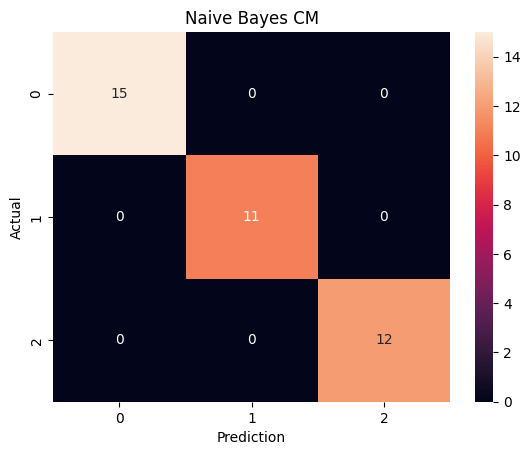

In [15]:
sns.heatmap(cm, annot = True)
plt.title('Naive Bayes CM')
plt.xlabel('Prediction')
plt.ylabel('Actual')